In [2]:
import numpy as np
from tensorflow.keras.models import Sequential

# RNN layer
from tensorflow.keras.layers import SimpleRNN

# Fully connected output layer
from tensorflow.keras.layers import Dense

# Converts word IDs into dense vectors
from tensorflow.keras.layers import Embedding

# Converts text into sequences of numbers
from tensorflow.keras.preprocessing.text import Tokenizer

# Makes all sequences the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

2026-05-28 10:05:46.276547: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779962746.585296      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779962746.676518      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779962747.492815      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779962747.492867      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779962747.492869      58 computation_placer.cc:177] computation placer alr

In [ ]:
texts = [
    
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever",
    "Wouldn't recommend wasting your time",
    "Highly recommended for wasting time",
    "Worth watching",
    "Extemely heartwarming."
    "Random shit",
    "Good stuff",
    "Better than previous movies but not the best amongst all"

]

# Labels
# 1 = Positive
# 0 = Negative

labels = np.array([
    1, 1, 1, 1,
    0, 0, 0, 0,
    0, 1, 1, 1,
    0, 1
])

In [ ]:
# Create tokenizer object
tokenizer = Tokenizer()

# Learn all unique words from the dataset and assign an integer ID to each word
tokenizer.fit_on_texts(texts)

# Create a dictionary:
# word -> integer ID
print("Word Index:")
print(tokenizer.word_index)

# Convert each sentence into a sequence of numbers based on the word index
sequences = tokenizer.texts_to_sequences(texts)
print("\nSequences:")
print(sequences)

# Example:

# "I love this movie"
# may become
# [3, 4, 1, 2]



In [ ]:
X = pad_sequences(
    sequences,
    maxlen=6, # Maximum length of sequences. Shorter sequences will be padded, longer ones will be truncated
)

print("\nPadded Sequences:")
print(X)

model = Sequential()


model.add(
    Embedding(

        # Vocabulary size
        input_dim=len(tokenizer.word_index) + 1,

        # Each word becomes a vector

        # with 8 dimensions

        output_dim=14,

        # Input sentence length

        input_length=6

    )

)

# Example:

#

# Word ID: 5

#

# becomes

#

# [0.24, -0.17, 0.88, ...]

#

# instead of a single integer.

# ------------------------------------------

# RNN Layer

# ------------------------------------------

model.add(

    SimpleRNN(

        # Number of memory units

        8

    )

)

# The RNN reads words one by one

#

# Word 1 --> Hidden State

# Word 2 --> Hidden State

# Word 3 --> Hidden State

# Word 4 --> Hidden State

#

# Previous information is carried forward

# through the hidden state.

# ------------------------------------------

# Output Layer

# ------------------------------------------

model.add(

    Dense(

        # One neuron because

        # we predict Positive/Negative

        1,

        activation='sigmoid'

    )

)

# Sigmoid output:

#

# 0.00 -> Negative

# 1.00 -> Positive

#

# Example:

#

# 0.92 = 92% Positive

# ==========================================

# STEP 5: Compile model

# ==========================================

model.compile(

    # Optimizer updates weights

    optimizer='adam',

    # Loss function for binary classification

    loss='binary_crossentropy',

    # Accuracy metric

    metrics=['accuracy']

)

# Show architecture

model.summary()

# ==========================================

# STEP 6: Train model

# ==========================================

model.fit(

    X,

    labels,

    # Number of complete passes

    # through training data

    epochs=200,

    # Suppress training output

    verbose=0

)

# ==========================================

# STEP 7: Test with new review

# ==========================================

new_text = [

    "Amazing acting and good story"

]

# Convert sentence into word IDs

new_sequence = tokenizer.texts_to_sequences(

    new_text

)

print("\nNew Sequence:")

print(new_sequence)

# Pad to length 4

new_padded = pad_sequences(

    new_sequence,

    maxlen=4

)

print("\nPadded Sequence:")

print(new_padded)

# Predict sentiment

prediction = model.predict(

    new_padded

)

print("\nPrediction Probability:")

print(prediction[0][0])

# Convert probability into class

if prediction[0][0] > 0.5:

    print("Sentiment: Positive 😊")

else:

    print("Sentiment: Negative ☹️")

In [39]:
import pandas as pd

# The official path where Kaggle stores this attached dataset
PATH = '/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'

# Load the dataframe
df = pd.read_csv(PATH)

# Check the data structure
print(df.shape)
df.head()

# 2. Take ONLY the first 30 rows
df_subset = df.head(30).copy()

# 3. Clean up missing values specifically in our text and sentiment columns
df_subset = df_subset.dropna(subset=['review', 'sentiment'])
print(df_subset.head(10))

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
5  Probably my all-time favorite movie, a story o...  positive
6  I sure would like to see a resurrection of a u...  positive
7  This show was an amazing, fresh & innovative i...  negative
8  Encouraged by the positive comments about this...  negative
9  If you like original gut wrenching laughter yo...  positive


In [35]:
reviews = df_subset['review'].dropna().tolist()
sentiment = df_subset[['sentiment']]
# Convert 'positive' to 1 and 'negative' to 0
labels = df_subset['sentiment'].map({'positive': 1, 'negative': 0})
labels = np.array(labels)

In [34]:
# Create tokenizer object
tokenizer = Tokenizer()

# Learn all unique words from the dataset and assign an integer ID to each word
tokenizer.fit_on_texts(reviews)

# Create a dictionary:
# word -> integer ID
print("Word Index:")
print(tokenizer.word_index)

# Convert each sentence into a sequence of numbers based on the word index
sequences = tokenizer.texts_to_sequences(reviews)
print("\nSequences:")
print(sequences)

# Example:

# "I love this movie"
# may become
# [3, 4, 1, 2]

Word Index:
{'the': 1, 'a': 2, 'of': 3, 'br': 4, 'and': 5, 'to': 6, 'is': 7, 'i': 8, 'it': 9, 'in': 10, 'this': 11, 'that': 12, 'was': 13, 'movie': 14, 'with': 15, 'as': 16, 'but': 17, 'for': 18, 'film': 19, 'not': 20, 'on': 21, 'all': 22, 'one': 23, 'be': 24, 'you': 25, 'have': 26, 'so': 27, 'are': 28, 'like': 29, "it's": 30, 'if': 31, 'by': 32, 'at': 33, 'what': 34, 'just': 35, 'me': 36, 'about': 37, 'or': 38, 'an': 39, 'from': 40, 'time': 41, 'some': 42, 'my': 43, 'more': 44, 'we': 45, 'very': 46, 'only': 47, 'no': 48, 'out': 49, 'when': 50, 'war': 51, 'first': 52, 'would': 53, 'his': 54, 'than': 55, 'good': 56, 'bad': 57, 'who': 58, 'has': 59, 'see': 60, 'story': 61, 'up': 62, 'will': 63, 'there': 64, 'much': 65, 'into': 66, 'even': 67, 'movies': 68, 'they': 69, 'its': 70, 'say': 71, 'too': 72, 'been': 73, 'them': 74, 'people': 75, 'another': 76, 'show': 77, 'he': 78, 'then': 79, 'most': 80, 'far': 81, 'little': 82, 'way': 83, 'do': 84, 'how': 85, 'b': 86, 'other': 87, 'which': 88,

In [50]:
X = pad_sequences(
    sequences,
    maxlen=150 # Maximum length of sequences. Shorter sequences are padded, longer are truncated
)

print("\nPadded Sequences Matrix Shape:", X.shape)
print("Labels Array Shape:", labels.shape)

# ==========================================
# MODEL ARCHITECTURE
# ==========================================
model = Sequential()

model.add(
    Embedding(
        # Vocabulary size (unique words found + 1 for padding token 0)
        input_dim=len(tokenizer.word_index) + 1,
        # Each word becomes a dense vector with 14 dimensions
        output_dim=14,
        # Input sentence sequence length matches our padding maxlen
        input_length=150
    )
)

# RNN Layer
model.add(
    SimpleRNN(
        # Number of recurrent memory units
        32
    )
)

# Output Layer
model.add(
    Dense(
        # One neuron for binary probability output (0 to 1)
        1,
        activation='sigmoid'
    )
)

# ==========================================
# STEP 5: Compile Model
# ==========================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model layout
model.summary()

# ==========================================
# STEP 6: Train Model
# ==========================================
print("\n--- Training model on 30 samples ---")
history = model.fit(
    X,
    labels,
    epochs=200,
    verbose=1 # Switched to 1 so you can actively watch the accuracy climb!
)

# ==========================================
# STEP 7: Test with New Review
# ==========================================
new_text = [
    "Good product and very healthy."
]

# Convert sentence into word IDs using your fitted tokenizer
new_sequence = tokenizer.texts_to_sequences(new_text)
print("\nNew Sequence IDs:", new_sequence)

# CRITICAL FIX: Match the training maxlen dimension (6 instead of 4)
new_padded = pad_sequences(
    new_sequence,
    maxlen=12
)
print("Corrected Padded Sequence (Length 10):")
print(new_padded)

# Predict sentiment
prediction = model.predict(new_padded)
print("\nPrediction Probability:", prediction[0][0])

# Convert probability into classification output
if prediction[0][0] > 0.5:
    print("Sentiment Prediction: Positive 😊")
else:
    print("Sentiment Prediction: Negative ☹️")


Padded Sequences Matrix Shape: (30, 150)
Labels Array Shape: (30,)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training model on 30 samples ---
Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5667 - loss: 0.6810
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9000 - loss: 0.6183
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9667 - loss: 0.5471
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9667 - loss: 0.4617
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.3850
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.3358
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.2936
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.2587
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 0.2283
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.2050
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 0.1879
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 

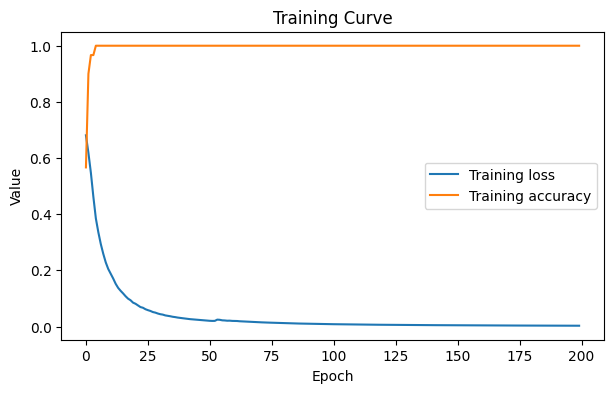

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['accuracy'], label = 'Training accuracy')
plt.title('Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

In [9]:
eng = ['The weather is nice today', 'I need water', 'Where is station', 'Hello', 'Good morning', 'Good evening', 'I am hungry', 'I love you', 'The cat is sleeping', 'Learning A1 if fun']
ger = ['Das wetter ist heute schon', 'Ich brauche wasser', 'Wo ist der Bahnhof', 'Hallo', 'Guten morgen', 'Guten Abend', 'Ich habe hunger', 'Ich liebe dich', 'Die katze schlaft', 'A1 zu lernen macht spas']

In [10]:
# 2. Initialize a separate Tokenizer for each language
eng_tokenizer = Tokenizer()
ger_tokenizer = Tokenizer()
 
# 3. Fit the tokenizers on the texts - builds the vocabulary dictionary
eng_tokenizer.fit_on_texts(eng)
ger_tokenizer.fit_on_texts(ger)
 
# 4. Convert the text sentences into sequences of numbers
eng_sequences = eng_tokenizer.texts_to_sequences(eng)
ger_sequences = ger_tokenizer.texts_to_sequences(ger)
 
# 5. Display the results
print("--- English Tokenizer ---")
print("Vocabulary:", eng_tokenizer.word_index)
print(eng_sequences)
 
print("\n--- German Tokenizer ---")
print("Vocabulary:", ger_tokenizer.word_index)
print(ger_sequences)

--- English Tokenizer ---
Vocabulary: {'is': 1, 'i': 2, 'the': 3, 'good': 4, 'weather': 5, 'nice': 6, 'today': 7, 'need': 8, 'water': 9, 'where': 10, 'station': 11, 'hello': 12, 'morning': 13, 'evening': 14, 'am': 15, 'hungry': 16, 'love': 17, 'you': 18, 'cat': 19, 'sleeping': 20, 'learning': 21, 'a1': 22, 'if': 23, 'fun': 24}
[[3, 5, 1, 6, 7], [2, 8, 9], [10, 1, 11], [12], [4, 13], [4, 14], [2, 15, 16], [2, 17, 18], [3, 19, 1, 20], [21, 22, 23, 24]]

--- German Tokenizer ---
Vocabulary: {'ich': 1, 'ist': 2, 'guten': 3, 'das': 4, 'wetter': 5, 'heute': 6, 'schon': 7, 'brauche': 8, 'wasser': 9, 'wo': 10, 'der': 11, 'bahnhof': 12, 'hallo': 13, 'morgen': 14, 'abend': 15, 'habe': 16, 'hunger': 17, 'liebe': 18, 'dich': 19, 'die': 20, 'katze': 21, 'schlaft': 22, 'a1': 23, 'zu': 24, 'lernen': 25, 'macht': 26, 'spas': 27}
[[4, 5, 2, 6, 7], [1, 8, 9], [10, 2, 11, 12], [13], [3, 14], [3, 15], [1, 16, 17], [1, 18, 19], [20, 21, 22], [23, 24, 25, 26, 27]]


In [7]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense  # Swapped SimpleRNN for LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# STEP 4: Pad Sequences
# ==========================================
# Making sure we consistently use maxlen=6 across English and German inputs
X = pad_sequences(
    eng_sequences,  # Using the English sequences we generated in the previous step
    maxlen=6 
)

print("\nPadded Sequences Matrix Shape:", X.shape)

# ==========================================
# MODEL ARCHITECTURE (LSTM)
# ==========================================
model = Sequential()

model.add(
    Embedding(
        # Vocabulary size based on the English tokenizer
        input_dim=len(eng_tokenizer.word_index) + 1,
        # Each word becomes a dense vector with 14 dimensions
        output_dim=14,
        # Sequence length
        input_length=6
    )
)

# ------------------------------------------
# LSTM Layer (Replaced SimpleRNN)
# ------------------------------------------
model.add(
    LSTM(
        # 8 memory cells with internal forget, input, and output gates
        8
    )
)

# ------------------------------------------
# Output Layer
# ------------------------------------------
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

# ==========================================
# STEP 5: Compile Model
# ==========================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show layout (Notice LSTM has 4x more parameters than SimpleRNN due to internal gates!)
model.summary()

# ==========================================
# STEP 6: Train Model
# ==========================================
print("\n--- Training LSTM model ---")
# Captured output in 'history' to allow for plotting later
history = model.fit(
    X,
    labels,
    epochs=200,
    verbose=1 
)

# ==========================================
# STEP 7: Test with New Review
# ==========================================
new_text = ["Amazing acting and good story"]

# Convert sentence into word IDs using the English tokenizer
new_sequence = eng_tokenizer.texts_to_sequences(new_text)
print("\nNew Sequence IDs:", new_sequence)

# Standardized to maxlen=6 to prevent dimension mismatch errors
new_padded = pad_sequences(
    new_sequence,
    maxlen=6
)
print("Padded Sequence (Length 6):")
print(new_padded)

# Predict sentiment
prediction = model.predict(new_padded)
print("\nPrediction Probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Sentiment Prediction: Positive 😊")
else:
    print("Sentiment Prediction: Negative ☹️")


Padded Sequences Matrix Shape: (11, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-05-28 10:09:12.788350: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training LSTM model ---


NameError: name 'labels' is not defined

In [11]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# STEP 1: Prepare Input (English) & Target (German) Data
# ==========================================
# 1. Pad English sequences to length 6 (Input features)
X_train = pad_sequences(
    eng_sequences, 
    maxlen=6
)

# 2. Pad German sequences to length 6 (Target labels)
# Replacing the old sentiment 'labels' with our German sequence targets!
Y_train = pad_sequences(
    ger_sequences,
    maxlen=6
)

print("English Input Shape (X_train):", X_train.shape)
print("German Target Shape (Y_train):", Y_train.shape)

# ==========================================
# STEP 2: Model Architecture with Explicit Input Layer
# ==========================================
model = Sequential()

# 1. Input Layer: Defines the shape of incoming English text matrices
model.add(Input(shape=(6,)))

# 2. Embedding Layer: Automatically handles input_length from the Input layer
model.add(
    Embedding(
        input_dim=len(eng_tokenizer.word_index) + 1,
        output_dim=14
    )
)

# 3. LSTM Layer
model.add(
    LSTM(8, return_sequences=True) 
)

# 4. Dense Output Layer: Maps to German vocabulary size
# Predicts the correct German word ID for each of the 6 sequence positions
model.add(
    Dense(
        units=len(ger_tokenizer.word_index) + 1, 
        activation='softmax'
    )
)

# ==========================================
# STEP 3: Compile & Train
# ==========================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Used when targets are integers (Word IDs)
    metrics=['accuracy']
)

model.summary()

print("\n--- Training Translation Model ---")
history = model.fit(
    X_train,
    Y_train,
    epochs=200,
    verbose=1
)

English Input Shape (X_train): (10, 6)
German Target Shape (Y_train): (10, 6)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 6, 14)          │           350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 6, 8)           │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6, 28)          │           252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,338 (5.23 KB)

 Trainable params: 1,338 (5.23 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Translation Model ---
Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4833 - loss: 3.3275
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 3.3235
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4833 - loss: 3.3194
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4833 - loss: 3.3153
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4833 - loss: 3.3111
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4833 - loss: 3.3068
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4833 - loss: 3.3024
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4833 - loss: 3.2979
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4833 - loss: 3.2933
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4833 - loss: 3.2886
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4833 - loss: 3.2837
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

In [14]:
# ==========================================
# STEP 7: Translate a new English sentence
# ==========================================
new_eng_text = ["Guten morgen"]

# 1. Convert English text into word IDs
new_seq = eng_tokenizer.texts_to_sequences(new_eng_text)

# 2. Pad to match the required input shape (6)
new_padded = pad_sequences(new_seq, maxlen=6)

# 3. Get raw probability distribution from the model
raw_prediction = model.predict(new_padded) 

# 4. For each word slot, find the index of the highest probability
# (argmax turns probabilities like [0.01, 0.95, 0.04] into a clean word ID: 1)
predicted_word_ids = np.argmax(raw_prediction, axis=-1)[0]

# 5. Convert those predicted word IDs back into a German string
predicted_ger_words = []
for word_id in predicted_word_ids:
    # Skip padding tokens (0)
    if word_id != 0:
        # Look up the ID in our tokenizer's reverse dictionary
        word = ger_tokenizer.index_word.get(word_id, "")
        if word:
            predicted_ger_words.append(word)

# Join the list of words into a single sentence string
final_translation = " ".join(predicted_ger_words)

print("\n--- Translation Results ---")
print("Input (English):", new_eng_text[0])
print("Output (German) :", final_translation)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

--- Translation Results ---
Input (English): Guten morgen
Output (German) : 


In [16]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# 1. BALANCED DATASETS (11 sentences each)
# ==========================================
eng = [
    'The weather is nice today', 'I need water', 'Where is station', 'Hello', 
    'Good morning', 'Good evening', 'Good Day', 'I am hungry', 'I love you', 
    'The cat is sleeping', 'Learning A1 if fun'
]
ger = [
    'Das wetter ist heute schon', 'Ich brauche wasser', 'Wo ist der Bahnhof', 'Hallo', 
    'Guten morgen', 'Guten Abend', 'Guten Tag', 'Ich habe hunger', 'Ich liebe dich', 
    'Die katze schlaft', 'A1 zu lernen macht spas'
]

# ==========================================
# 2. TOKENIZATION & PADDING
# ==========================================
eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(eng)
eng_sequences = eng_tokenizer.texts_to_sequences(eng)

ger_tokenizer = Tokenizer()
ger_tokenizer.fit_on_texts(ger)
ger_sequences = ger_tokenizer.texts_to_sequences(ger)

X_train = pad_sequences(eng_sequences, maxlen=6)
Y_train = pad_sequences(ger_sequences, maxlen=6)

# ==========================================
# 3. STACKED MODEL ARCHITECTURE (RNN -> LSTM)
# ==========================================
model = Sequential()

# Input layer (Accepting 6-word English sequence IDs)
model.add(Input(shape=(6,)))

# Embedding layer
model.add(
    Embedding(
        input_dim=len(eng_tokenizer.word_index) + 1,
        output_dim=14
    )
)

# FIRST RECURRENT LAYER: SimpleRNN
# CRITICAL: return_sequences=True passes a 3D tensor to the next layer
model.add(
    SimpleRNN(8, return_sequences=True)
)

# SECOND RECURRENT LAYER: LSTM
# This sits on top of the RNN and processes its sequence outputs
model.add(
    LSTM(8, return_sequences=True)
)

# Output layer mapping to German vocabulary
model.add(
    Dense(
        units=len(ger_tokenizer.word_index) + 1, 
        activation='softmax'
    )
)

# ==========================================
# 4. COMPILE AND TRAIN
# ==========================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Model Architecture Summary ---")
model.summary()

print("\n--- Training Stacked Model ---")
history = model.fit(X_train, Y_train, epochs=200, verbose=0)
print("Training completed successfully!")

# ==========================================
# 5. TEST AND DECODE OUTPUT TO GERMAN
# ==========================================
new_eng_text = ["I love the weather today"]

# Process input string
new_seq = eng_tokenizer.texts_to_sequences(new_eng_text)
new_padded = pad_sequences(new_seq, maxlen=6)

# Get prediction matrix from stacked model
raw_prediction = model.predict(new_padded) 
predicted_word_ids = np.argmax(raw_prediction, axis=-1)[0]

# Decode word IDs back into German text
predicted_ger_words = []
for word_id in predicted_word_ids:
    if word_id != 0: # Skip padding tokens
        word = ger_tokenizer.index_word.get(word_id, "")
        if word:
            predicted_ger_words.append(word)

final_translation = " ".join(predicted_ger_words)

print("\n--- Translation Results ---")
print("Input (English):", new_eng_text[0])
print("Output (German) :", final_translation)

--- Model Architecture Summary ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 6, 14)          │           364 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 6, 8)           │           184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 6, 8)           │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6, 29)          │           261 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,353 (5.29 KB)

 Trainable params: 1,353 (5.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Stacked Model ---
Training completed successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step

--- Translation Results ---
Input (English): I love the weather today
Output (German) : ist ist ist


In [4]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Embedding, RepeatVector
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
 
# 1. THE DATA
# ==========================================
english_sentences = [
    "The weather is nice today", "I need water", "Where is station",
    "hello", "good morning", "good evening", "I am hungry",
    "I love you", "The cat is sleeping", "Learning AI is fun"
]
 
german_sentences = [
    "Das wetter ist heute schön", "Ich brauche wasser", "Wo ist der Bahnhof",
    "hallo", "guten morgen", "guten Abend", "Ich habe hunger",
    "Ich liebe dich", "Die katze schläft", "KI zu lernen macht spaß"
]
 
# ==========================================
# 2. TOKENIZATION & PADDING
# ==========================================
# Tokenize English (Inputs)
eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(english_sentences)
eng_vocab_size = len(eng_tokenizer.word_index) + 1
 
X_seq = eng_tokenizer.texts_to_sequences(english_sentences)
max_eng_len = max(len(seq) for seq in X_seq)
X = pad_sequences(X_seq, maxlen=max_eng_len, padding='post')
 
# Tokenize German (Targets)
ger_tokenizer = Tokenizer()
ger_tokenizer.fit_on_texts(german_sentences)
ger_vocab_size = len(ger_tokenizer.word_index) + 1
 
Y_seq = ger_tokenizer.texts_to_sequences(german_sentences)
max_ger_len = max(len(seq) for seq in Y_seq)
Y = pad_sequences(Y_seq, maxlen=max_ger_len, padding='post')
 
# Neural networks expect a 3D target array for sequence output
Y = Y.reshape(Y.shape[0], Y.shape[1], 1)
 
# ==========================================
# 3. BUILD THE HYBRID SEQUENTIAL MODEL
# ==========================================
model = Sequential()
 
# --- ENCODER (Reads the English) ---
model.add(Embedding(input_dim=eng_vocab_size, output_dim=16))
 
# The RNN reads the sequence first.
# return_sequences=True is MANDATORY here so it passes the full sequence to the LSTM
model.add(SimpleRNN(32, return_sequences=True))
 
# The LSTM reads the RNN's output and compresses it into one final memory vector
model.add(LSTM(32))
 
# --- THE BRIDGE ---
# We repeat that final memory vector for every German word we want to output
model.add(RepeatVector(max_ger_len))
 
# --- DECODER (Writes the German) ---
# return_sequences=True forces the output of a prediction for every single word step
model.add(LSTM(32, return_sequences=True))
model.add(Dense(ger_vocab_size, activation='softmax'))
 
# ==========================================
# 4. COMPILE AND TRAIN
# ==========================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 
model.summary()
 
print("Training model...")
# Increased epochs slightly because the stacked layers take a bit longer to learn
model.fit(X, Y, epochs=250, verbose=0)
print("Training complete!")
 
# ==========================================
# 5. TEST THE TRANSLATOR
# ==========================================
test_sentence = english_sentences[1] 
 
# CRITICAL FIX: Wrap the single string in a list [ ]
test_seq = eng_tokenizer.texts_to_sequences([test_sentence]) 
test_padded = pad_sequences(test_seq, maxlen=max_eng_len, padding='post')
 
# Predict the German sequence
prediction = model.predict(test_padded, verbose=0)
 
# Grab the highest probability word ID for each step
predicted_word_ids = np.argmax(prediction[0], axis=-1)
 
# Reverse dictionary to turn numbers back into German words
ger_index_word = {v: k for k, v in ger_tokenizer.word_index.items()}
 
translated_words = []
for word_id in predicted_word_ids:
    if word_id != 0: # Ignore the padding zeros
        translated_words.append(ger_index_word.get(word_id, ""))
 
# FIXED PRINT: Print the actual full sentence string
print(f"\nEnglish Input : {test_sentence}")
print(f"German Output : {' '.join(translated_words)}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training model...
Training complete!

English Input : I need water
German Output : ich brauche wasser
